In [19]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
import statsmodels.api as sm
import matplotlib.pyplot as plt
import gc
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# FEATURE SETS
# ============================================================

VALUE    = ['bm','bm_ia','cfp','cfp_ia','ep','sp','dy']

QUALITY  = ['roaq','roeq','gma','operprof',
            'acc','absacc','pctacc',
            'tb','cashdebt','stdacc',
            'agr','egr','lgr','invest',
            'lev','ms','nincr']

MOMENTUM = ['mom1m','mom6m','mom12m','mom36m','chmom','indmom']

FEATURE_SETS = {
    'A_Value':           VALUE,
    'B_ValueQuality':    VALUE + QUALITY,
    'C_ValueQualityMom': VALUE + QUALITY + MOMENTUM,
}

TARGET = 'ret'


In [20]:

# ============================================================
# STEP 1: LOAD KELLY DATASET
# ============================================================

print("Loading Kelly dataset...")

all_features = VALUE + QUALITY + MOMENTUM
load_cols    = ['permno','date',TARGET] + all_features

chunks = []
for chunk in pd.read_csv('kelly_final.csv',
                          usecols=lambda c: c in load_cols,
                          chunksize=500000,
                          parse_dates=['date']):
    chunks.append(chunk)

kelly = pd.concat(chunks, ignore_index=True)
kelly = kelly.sort_values(['permno','date']).reset_index(drop=True)

del chunks
gc.collect()

print(f"Kelly rows: {len(kelly):,}")
print(f"Date range: {kelly['date'].min()} to {kelly['date'].max()}")

# ============================================================
# STEP 2: LOAD EXTENSION DATASET
# ============================================================

print("\nLoading extension dataset...")
ext = pd.read_csv('features_2022_2024.csv', parse_dates=['date'])
ext = ext.sort_values(['permno','date']).reset_index(drop=True)

print(f"Extension rows: {len(ext):,}")
print(f"Date range: {ext['date'].min()} to {ext['date'].max()}")


Loading Kelly dataset...
Kelly rows: 3,895,198
Date range: 1957-01-01 00:00:00 to 2021-12-01 00:00:00

Loading extension dataset...
Extension rows: 180,123
Date range: 2022-01-01 00:00:00 to 2024-11-01 00:00:00


In [21]:

# ============================================================
# STEP 3: RANK NORMALIZATION
# ============================================================

def rank_normalize(df, feature_cols):
    df = df.copy()

    def cs_rank(x):
        r = x.rank(method='average')
        if len(r) <= 1:
            return r * 0
        return (r - 1) / (len(r) - 1) * 2 - 1

    df[feature_cols] = df.groupby('date')[feature_cols].transform(
        lambda x: x.fillna(x.median())
    )
    df[feature_cols] = df[feature_cols].fillna(0)
    df[feature_cols] = df.groupby('date')[feature_cols].transform(cs_rank)

    return df

# ============================================================
# STEP 4: DOWNLOAD FF5 FACTORS
# ============================================================

def get_ff5():
    import requests, zipfile, io

    url = ("https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/"
           "ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip")

    print("Downloading FF5 factors...")
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))

    with z.open(z.namelist()[0]) as f:
        raw = f.read().decode('utf-8')

    lines = raw.split('\n')
    start = 0
    for i, line in enumerate(lines):
        stripped = line.strip()
        if (stripped and stripped[0].isdigit()
                and len(stripped.split(',')[0].strip()) == 6):
            start = i
            break

    from io import StringIO
    ff5 = pd.read_csv(
        StringIO('\n'.join(lines[start:])),
        header=None,
        names=['date','MKT','SMB','HML','RMW','CMA','RF'],
        on_bad_lines='skip'
    )
    ff5 = ff5[ff5['date'].astype(str).str.strip().str.len() == 6]
    ff5['date'] = pd.to_datetime(
        ff5['date'].astype(str).str.strip(), format='%Y%m'
    )
    ff5 = ff5.set_index('date')
    ff5 = ff5.apply(pd.to_numeric, errors='coerce') / 100
    ff5 = ff5.dropna()

    print(f"FF5 loaded: {ff5.index[0]} to {ff5.index[-1]}")
    return ff5

ff5 = get_ff5()

# RF series indexed by month for use in metrics
rf_series = ff5['RF']


FF5 loaded: 1963-07-01 00:00:00 to 2026-01-01 00:00:00


In [22]:

# ============================================================
# STEP 5: PERFORMANCE METRICS (period-specific RF) 
# ============================================================

def compute_metrics(returns, name='Strategy', rf=None):
    """
    Compute performance metrics using period-specific risk-free rate.
    rf should be a Series aligned with returns index.
    If rf is None, defaults to 0.
    """
    returns = returns.dropna()

    if rf is not None:
        rf_aligned = rf.reindex(returns.index).fillna(0)
    else:
        rf_aligned = pd.Series(0, index=returns.index)

    excess   = returns - rf_aligned
    ann_ret  = (1 + returns).prod() ** (12/len(returns)) - 1
    ann_rf   = (1 + rf_aligned).prod() ** (12/len(rf_aligned)) - 1
    ann_vol  = returns.std() * np.sqrt(12)
    sharpe   = excess.mean() / excess.std() * np.sqrt(12)
    cum      = (1 + returns).cumprod()
    max_dd   = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar   = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    hit_rate = (returns > 0).mean()
    skew     = returns.skew()
    kurt     = returns.kurt()

    return {
        'Name':       name,
        'Ann Return': f"{ann_ret:.2%}",
        'Ann RF':     f"{ann_rf:.2%}",
        'Ann Vol':    f"{ann_vol:.2%}",
        'Sharpe':     f"{sharpe:.2f}",
        'Max DD':     f"{max_dd:.2%}",
        'Calmar':     f"{calmar:.2f}",
        'Hit Rate':   f"{hit_rate:.1%}",
        'Skew':       f"{skew:.2f}",
        'Kurt':       f"{kurt:.2f}",
    }

def compute_yearly_metrics(returns, name='Strategy', rf=None):
    """
    Compute annual return, Sharpe, and max DD for each calendar year.
    Uses monthly RF for that year.
    """
    returns = returns.dropna()

    if rf is not None:
        rf_aligned = rf.reindex(returns.index).fillna(0)
    else:
        rf_aligned = pd.Series(0, index=returns.index)

    rows = []
    for year in sorted(returns.index.year.unique()):
        yr_ret = returns[returns.index.year == year]
        yr_rf  = rf_aligned[rf_aligned.index.year == year]

        if len(yr_ret) < 3:
            continue

        excess_yr = yr_ret - yr_rf
        ann_ret   = (1 + yr_ret).prod() - 1       # actual year return
        ann_vol   = yr_ret.std() * np.sqrt(12)
        sharpe    = (excess_yr.mean() / excess_yr.std()
                     * np.sqrt(12)) if excess_yr.std() > 0 else np.nan
        cum       = (1 + yr_ret).cumprod()
        max_dd    = ((cum - cum.cummax()) / cum.cummax()).min()

        rows.append({
            'Year':       year,
            'Name':       name,
            'Ann Return': ann_ret,
            'Ann Vol':    ann_vol,
            'Sharpe':     sharpe,
            'Max DD':     max_dd,
            'N Months':   len(yr_ret),
        })

    return pd.DataFrame(rows)


In [23]:

# ============================================================
# STEP 6: FF5 LINEAR BENCHMARK STRATEGY
#
# This is a proper benchmark: each month we estimate expected
# returns for each stock using the FF5 factor loadings, then
# form a long-short portfolio on predicted returns — exactly
# the same construction as our ML strategy.
#
# Methodology:
# 1. For each stock, run rolling 60-month OLS: r_i = a + b*MKT
#    + c*SMB + d*HML + e*RMW + f*CMA + eps
# 2. Multiply estimated betas by current month's factor realizations
#    to get expected return: E[r_i] = b*MKT_t + c*SMB_t + ...
# 3. Rank stocks by E[r_i], go long top decile / short bottom decile
# 4. Apply same 50bps TC as ML strategy
#
# This is a fair benchmark because:
# - It uses the same information set (factor realizations)
# - Same portfolio construction (decile long-short)
# - Same transaction costs
# - It represents the best a linear factor investor can do
# ============================================================

def run_ff5_benchmark(kelly_df, ext_df,
                      test_start       = '2006-01-01',
                      test_end         = '2021-12-01',
                      ext_start        = '2022-01-01',
                      ext_end          = '2024-11-01',
                      rolling_window   = 60,
                      n_deciles        = 10,
                      transaction_cost = 0.0050):
    """
    Vectorized FF5 benchmark using CuPy for GPU acceleration.
    All matrix operations (OLS, predictions) run on GPU.
    Only portfolio construction stays on CPU (pandas).
    """
    print("\n" + "="*60)
    print("Running FF5 Linear Benchmark (Vectorized + CuPy GPU)")
    print(f"Rolling window: {rolling_window} months")
    print(f"TC: {transaction_cost*10000:.0f} bps one-way")
    print("="*60)

    # ── CuPy setup ─────────────────────────────────────────────
    try:
        import cupy as cp
        from cupy.linalg import inv as cp_inv
        USE_GPU = True
        print("CuPy available — running on GPU")
        # Warm up GPU
        _ = cp.array([1.0])
        cp.cuda.Stream.null.synchronize()
    except ImportError:
        USE_GPU = False
        print("CuPy not available — falling back to NumPy CPU")
        cp = np  # transparent fallback

    # ── Build return matrix ────────────────────────────────────
    print("\nBuilding return matrix...")
    kelly_rets = kelly_df[['permno','date','ret']].copy()
    ext_rets   = ext_df[['permno','date','ret']].copy()
    all_rets   = pd.concat([kelly_rets, ext_rets], ignore_index=True)

    ret_matrix = all_rets.pivot(index='date', columns='permno', values='ret')
    ret_matrix = ret_matrix.sort_index()

    N_dates  = len(ret_matrix.index)
    N_stocks = len(ret_matrix.columns)
    print(f"Return matrix: {N_dates} dates × {N_stocks} stocks")

    # Align factors
    factors = ff5[['MKT','SMB','HML','RMW','CMA']].reindex(ret_matrix.index)

    # ── Transfer static data to GPU once ──────────────────────
    # We transfer the full matrices to GPU upfront.
    # Each monthly step just slices — no repeated transfers.
    print("Transferring data to GPU..." if USE_GPU else "Preparing arrays...")

    ret_vals_np = ret_matrix.values.astype(np.float32)   # (T, N) float32 saves VRAM
    fac_vals_np = factors.values.astype(np.float32)       # (T, 5)

    if USE_GPU:
        ret_gpu = cp.array(ret_vals_np)   # full return matrix on GPU
        fac_gpu = cp.array(fac_vals_np)   # full factor matrix on GPU
        ones_w  = cp.ones((rolling_window, 1), dtype=cp.float32)
        print(f"GPU memory used: "
              f"{cp.get_default_memory_pool().used_bytes() / 1e9:.2f} GB")
    else:
        ret_gpu = ret_vals_np
        fac_gpu = fac_vals_np
        ones_w  = np.ones((rolling_window, 1), dtype=np.float32)

    # ── Permno labels and date index ──────────────────────────
    permnos    = ret_matrix.columns.values
    date_index = ret_matrix.index

    all_dates = sorted(pd.date_range(test_start, ext_end, freq='MS'))
    all_dates = [d for d in all_dates if d in date_index]
    print(f"Processing {len(all_dates)} months...")

    results            = []
    prev_long_permnos  = set()
    prev_short_permnos = set()

    for t_idx, test_date in enumerate(all_dates):

        if t_idx % 12 == 0:
            print(f"  [{test_date.strftime('%Y-%m')}] "
                  f"processed {t_idx}/{len(all_dates)}")

        date_pos = date_index.get_loc(test_date)

        if date_pos < rolling_window:
            continue

        # ── Slice window — operates on GPU arrays directly ────
        window_slice = slice(date_pos - rolling_window, date_pos)

        F = fac_gpu[window_slice]          # (W, 5) on GPU
        R = ret_gpu[window_slice]          # (W, N) on GPU

        # Add intercept: X shape (W, 6)
        X = cp.hstack([ones_w, F]) if USE_GPU else np.hstack([ones_w, F])

        # ── Vectorized OLS: B = (X'X)^{-1} X'R ───────────────
        # Handles all N stocks simultaneously
        # B shape: (6, N) — one column of betas per stock
        try:
            XtX     = X.T @ X              # (6, 6)
            XtX_inv = cp_inv(XtX) if USE_GPU else np.linalg.inv(XtX)
            XtR     = X.T @ R              # (6, N)
            B       = XtX_inv @ XtR        # (6, N)
        except Exception:
            continue

        # ── Current month factors → predicted returns ──────────
        # curr_X shape: (6,) — intercept + 5 factors
        curr_f_np = fac_vals_np[date_pos]                  # always numpy for indexing
        curr_X_np = np.array([1.0, *curr_f_np], dtype=np.float32)

        if USE_GPU:
            curr_X_gpu = cp.array(curr_X_np)               # (6,) on GPU
            pred_gpu   = curr_X_gpu @ B                    # (N,) predicted returns
        else:
            pred_gpu   = curr_X_np @ B                     # (N,)

        # ── Valid stock mask ───────────────────────────────────
        # Need >= 24 non-NaN observations in window
        # And current month return must be non-NaN
        if USE_GPU:
            nan_count    = cp.isnan(R).sum(axis=0)         # (N,)
            valid_window = (rolling_window - nan_count) >= 24
            curr_rets_gpu = ret_gpu[date_pos]              # (N,)
            valid_curr   = ~cp.isnan(curr_rets_gpu)
            valid_mask   = valid_window & valid_curr       # (N,) bool

            # Bring results back to CPU for portfolio construction
            pred_np      = cp.asnumpy(pred_gpu)
            curr_rets_np = cp.asnumpy(curr_rets_gpu)
            valid_np     = cp.asnumpy(valid_mask)

        else:
            nan_count    = np.isnan(R).sum(axis=0)
            valid_window = (rolling_window - nan_count) >= 24
            curr_rets_np = ret_vals_np[date_pos]
            valid_curr   = ~np.isnan(curr_rets_np)
            valid_np     = valid_window & valid_curr
            pred_np      = pred_gpu
            curr_rets_np = curr_rets_np

        valid_idx = np.where(valid_np)[0]

        if len(valid_idx) < 50:
            continue

        # ── Portfolio construction (CPU) ───────────────────────
        pred_df = pd.DataFrame({
            'permno': permnos[valid_idx],
            'pred':   pred_np[valid_idx],
            'ret':    curr_rets_np[valid_idx],
        })

        try:
            pred_df['decile'] = pd.qcut(
                pred_df['pred'], n_deciles,
                labels=False, duplicates='drop'
            )
        except ValueError:
            continue

        long_df  = pred_df[pred_df['decile'] == n_deciles - 1]
        short_df = pred_df[pred_df['decile'] == 0]

        if len(long_df) == 0:
            continue

        long_ret_gross  = long_df['ret'].mean()
        short_ret_gross = short_df['ret'].mean() if len(short_df) > 0 else 0

        curr_long  = set(long_df['permno'].values)
        curr_short = set(short_df['permno'].values)

        long_turnover  = (len(curr_long  - prev_long_permnos)  /
                          len(curr_long))  if prev_long_permnos  else 1.0
        short_turnover = (len(curr_short - prev_short_permnos) /
                          len(curr_short)) if prev_short_permnos else 1.0

        long_ret_net  = long_ret_gross  - long_turnover  * transaction_cost
        short_ret_net = short_ret_gross + short_turnover * transaction_cost
        ls_ret_net    = long_ret_net    - short_ret_net
        ls_ret_gross  = long_ret_gross  - short_ret_gross

        prev_long_permnos  = curr_long
        prev_short_permnos = curr_short

        results.append({
            'date':          test_date,
            'long_ret':      long_ret_net,
            'short_ret':     short_ret_net,
            'ls_ret':        ls_ret_net,
            'ls_ret_gross':  ls_ret_gross,
            'long_turnover': long_turnover,
            'short_turnover':short_turnover,
            'avg_turnover':  (long_turnover + short_turnover) / 2,
            'n_stocks':      len(pred_df),
        })

    # ── Cleanup GPU memory ─────────────────────────────────────
    if USE_GPU:
        del ret_gpu, fac_gpu, ones_w
        cp.get_default_memory_pool().free_all_blocks()
        print(f"GPU memory freed")

    port = pd.DataFrame(results).set_index('date')
    print(f"\nFF5 benchmark months: {len(port)}")
    print(f"Avg monthly turnover: {port['avg_turnover'].mean():.1%}")

    return port

In [24]:

# ============================================================
# STEP 7: PORTFOLIO BUILDER WITH TRANSACTION COSTS
# ============================================================

def build_portfolio_with_costs(month_df, n_deciles, date,
                                prev_long, prev_short, tc):
    try:
        month_df = month_df.copy()
        month_df['decile'] = pd.qcut(
            month_df['pred'], n_deciles,
            labels=False, duplicates='drop'
        )
    except ValueError:
        return None

    actual_max = month_df['decile'].max()
    actual_min = month_df['decile'].min()

    # Guard: need at least 2 distinct deciles to form long and short
    if actual_max == actual_min or pd.isna(actual_max):
        return None

    long_df  = month_df[month_df['decile'] == actual_max]
    short_df = month_df[month_df['decile'] == actual_min]

    if len(long_df) == 0:
        return None

    long_ret_gross  = long_df[TARGET].mean()
    short_ret_gross = short_df[TARGET].mean() if len(short_df) > 0 else 0

    curr_long  = set(long_df['permno'].values)
    curr_short = set(short_df['permno'].values)

    long_turnover  = (len(curr_long  - prev_long)  / len(curr_long))  if prev_long  else 1.0
    short_turnover = (len(curr_short - prev_short) / len(curr_short)) if prev_short else 1.0

    long_ret_net  = long_ret_gross  - long_turnover  * tc
    short_ret_net = short_ret_gross + short_turnover * tc
    ls_ret_net    = long_ret_net    - short_ret_net
    ls_ret_gross  = long_ret_gross  - short_ret_gross

    return {
        'date':          date,
        'long_ret':      long_ret_net,
        'short_ret':     short_ret_net,
        'ls_ret':        ls_ret_net,
        'ls_ret_gross':  ls_ret_gross,
        'long_turnover': long_turnover,
        'short_turnover':short_turnover,
        'avg_turnover':  (long_turnover + short_turnover) / 2,
        'n_long':        len(long_df),
        'n_short':       len(short_df),
        'mkt_ret':       month_df[TARGET].mean(),
        'long_permnos':  curr_long,
        'short_permnos': curr_short,
    }

In [ ]:

DEVICE = 'cuda'  # 'cuda' for GPU, 'cpu' for CPU
# ============================================================
# STEP 8: ROBUST NaN HANDLER + ML BACKTEST ENGINE
# Train: 1957-2005
# OOS:   2006-2021
# Ext:   2022-2024
# ============================================================

def prepare_training_data(train_df, feature_cols, target_col='ret'):
    """
    Prepare training data with robust NaN handling.
    Consistent with rank_normalize at prediction time.
    
    1. Drop rows where target is NaN
    2. Fill feature NaNs with column median
    3. Fill remaining NaNs (all-NaN columns) with 0
    4. Clip to [-10, 10]
    5. Final finite check
    """
    train = train_df.dropna(subset=[target_col]).copy()

    X = train[feature_cols].copy()
    y = train[target_col].values

    col_medians = X.median()
    X = X.fillna(col_medians).fillna(0).clip(-10, 10)

    X_vals = X.values
    mask   = np.isfinite(X_vals).all(axis=1) & np.isfinite(y) # remove

    return X_vals[mask], y[mask]


def predict_month(month_df, feature_cols, model):
    """
    Predict returns for a single month with robust NaN handling.
    Consistent with prepare_training_data.
    """
    X_pred = (month_df[feature_cols]
              .fillna(month_df[feature_cols].median())
              .fillna(0)
              .clip(-10, 10)
              .values)
    return model.predict(X_pred)


def make_xgb(device):
    return XGBRegressor(
        n_estimators      = 500,
        learning_rate     = 0.01,
        max_depth         = 6, #10+15+0.6+0.7 not great
        min_child_weight  = 20, #20
        subsample         = 0.5, #0.5
        colsample_bytree  = 0.5, #0.5
        reg_alpha         = 0.1,
        reg_lambda        = 0.1,
        random_state      = 42,
        verbosity         = 0,
        device            = device,
        tree_method       = 'hist',
    )


def run_backtest(kelly_df, ext_df, feature_cols, model_name,
                 train_end        = '2005-12-01',
                 test_start       = '2006-01-01',
                 test_end         = '2021-12-01',
                 ext_start        = '2022-01-01',
                 ext_end          = '2024-11-01',
                 retrain_freq     = 12,
                 n_deciles        = 10,
                 transaction_cost = 0.0050):

    print(f"\n{'='*60}")
    print(f"Model: {model_name} | Features: {len(feature_cols)}")
    print(f"Train: 1957 to {train_end} (expanding window)")
    print(f"OOS:   {test_start} to {test_end}")
    print(f"Ext:   {ext_start} to {ext_end}")
    print(f"TC:    {transaction_cost*10000:.0f} bps one-way")
    print(f"{'='*60}")

    print("Rank normalizing...")
    kelly_proc = rank_normalize(kelly_df, feature_cols)
    ext_proc   = rank_normalize(ext_df,   feature_cols)

    test_dates = sorted(kelly_proc[
        (kelly_proc['date'] >= test_start) &
        (kelly_proc['date'] <= test_end)
    ]['date'].unique())

    ext_dates = sorted(ext_proc[
        (ext_proc['date'] >= ext_start) &
        (ext_proc['date'] <= ext_end)
    ]['date'].unique())

    results            = []
    model              = None
    last_retrain_year  = None          # track by calendar year, not index
    prev_long_permnos  = set()
    prev_short_permnos = set()

    # ----------------------------------------------------------
    # Pre-train on data strictly before test_start
    # This guarantees we always have a model from day one
    # ----------------------------------------------------------
    print(f"\nPre-training on data before {test_start}...")
    pretrain = kelly_proc[kelly_proc['date'] < test_start]
    X_pre, y_pre = prepare_training_data(pretrain, feature_cols)

    if len(y_pre) < 1000:
        raise ValueError(
            f"Only {len(y_pre)} obs before test_start — "
            f"check kelly_proc date range"
        )

    model = make_xgb(DEVICE)
    model.fit(X_pre, y_pre)
    last_retrain_year = pd.Timestamp(test_start).year - 1
    print(f"  Pre-trained on {len(y_pre):,} obs — model ready")

    # ----------------------------------------------------------
    # OOS BACKTEST: 2006-2021
    # Retrain at the START of each calendar year using all
    # data available strictly before that year.
    # Because we always have a pre-trained model, no month
    # is ever skipped due to a missing retrain.
    # ----------------------------------------------------------
    print(f"\nRunning OOS backtest ({len(test_dates)} months)...")

    for test_date in test_dates:

        current_year = test_date.year

        # Retrain once per calendar year — on the first month of each year
        if current_year != last_retrain_year:

            train      = kelly_proc[kelly_proc['date'] < test_date]
            X_tr, y_tr = prepare_training_data(train, feature_cols)

            if len(y_tr) < 1000:
                print(f"  [{test_date.strftime('%Y-%m')}] "
                      f"WARNING: only {len(y_tr):,} obs — keeping previous model")
            else:
                new_model = make_xgb(DEVICE)
                new_model.fit(X_tr, y_tr)
                model            = new_model
                last_retrain_year = current_year
                print(f"  [{test_date.strftime('%Y-%m')}] "
                      f"Retrained on {len(y_tr):,} obs")

        # Always predict — model is always valid (pre-trained above)
        month_df = kelly_proc[kelly_proc['date'] == test_date].copy()
        if len(month_df) < 20:
            continue

        month_df['pred'] = predict_month(month_df, feature_cols, model)

        result = build_portfolio_with_costs(
            month_df, n_deciles, test_date,
            prev_long_permnos, prev_short_permnos,
            transaction_cost
        )

        if result:
            prev_long_permnos  = result.pop('long_permnos')
            prev_short_permnos = result.pop('short_permnos')
            results.append(result)

    # ----------------------------------------------------------
    # EXTENSION: 2022-2024
    # Train on full Kelly (1957-2021) — same logic
    # ----------------------------------------------------------
    print(f"\nRunning extension ({len(ext_dates)} months)...")

    X_full, y_full = prepare_training_data(kelly_proc, feature_cols)
    print(f"  Training on {len(y_full):,} obs...")

    model_full = make_xgb(DEVICE)
    model_full.fit(X_full, y_full)
    print(f"  Done.")

    prev_long_permnos  = set()
    prev_short_permnos = set()

    for ext_date in ext_dates:
        month_df = ext_proc[ext_proc['date'] == ext_date].copy()
        if len(month_df) < 20:
            continue

        month_df['pred'] = predict_month(month_df, feature_cols, model_full)

        result = build_portfolio_with_costs(
            month_df, n_deciles, ext_date,
            prev_long_permnos, prev_short_permnos,
            transaction_cost
        )

        if result:
            prev_long_permnos  = result.pop('long_permnos')
            prev_short_permnos = result.pop('short_permnos')
            results.append(result)

    # ----------------------------------------------------------
    # Assemble + report
    # ----------------------------------------------------------
    port = pd.DataFrame(results).set_index('date')

    expected = pd.date_range(port.index.min(), port.index.max(), freq='MS')
    missing  = expected.difference(port.index)

    print(f"\nDone.")
    print(f"  Total months:         {len(port)}")
    print(f"  Period:               {port.index.min().strftime('%Y-%m')} "
          f"to {port.index.max().strftime('%Y-%m')}")
    print(f"  Missing months:       {len(missing)}")
    if len(missing) > 0:
        print(f"  Missing dates:        {missing.tolist()}")
    print(f"  Avg monthly turnover: {port['avg_turnover'].mean():.1%}")
    print(f"  Implied annual TC:    "
          f"{port['avg_turnover'].mean()*transaction_cost*12*100:.1f}%")

    return port, model_full


In [26]:

# ============================================================
# STEP 9: GPU CHECK
# ============================================================

try:
    test = XGBRegressor(device='cuda', n_estimators=10, verbosity=0)
    test.fit([[1,2],[3,4]], [1,0])
    print("CUDA confirmed — using GPU")
    DEVICE = 'cuda'
except Exception:
    print("No CUDA — using CPU")
    DEVICE = 'cpu'


CUDA confirmed — using GPU


In [27]:
# ============================================================
# DIAGNOSTIC — run this BEFORE the backtest to find the root cause
# ============================================================
"""
print("=" * 60)
print("DIAGNOSTIC: Why are months missing?")
print("=" * 60)

for model_name, feature_cols in FEATURE_SETS.items():
    print(f"\n--- {model_name} ({len(feature_cols)} features) ---")

    # Step 1: Check kelly_proc date range
    kelly_proc = rank_normalize(kelly, feature_cols)

    print(f"kelly_proc date range: "
          f"{kelly_proc['date'].min()} to {kelly_proc['date'].max()}")
    print(f"kelly_proc total rows: {len(kelly_proc):,}")

    # Step 2: Check what prepare_training_data returns for the pretrain
    pretrain = kelly_proc[kelly_proc['date'] < '2006-01-01']
    print(f"Pretrain rows (before 2006): {len(pretrain):,}")

    X_pre, y_pre = prepare_training_data(pretrain, feature_cols)
    print(f"After prepare_training_data: {len(y_pre):,} valid obs")

    # Step 3: Check January 2006 specifically
    jan2006 = kelly_proc[kelly_proc['date'] == '2006-01-01']
    print(f"Stocks in Jan 2006: {len(jan2006)}")
    if len(jan2006) > 0:
        nan_pct = jan2006[feature_cols].isna().mean()
        print(f"NaN % per feature in Jan 2006:")
        print(nan_pct[nan_pct > 0].to_string())

    # Step 4: Check feature-by-feature what's causing the pretrain to shrink
    print(f"\nFeature NaN % in pretrain data (before rank_normalize):")
    pretrain_raw = kelly[kelly['date'] < '2006-01-01']
    nan_by_feat = pretrain_raw[feature_cols].isna().mean().sort_values(ascending=False)
    print(nan_by_feat.head(10).to_string())

    # Step 5: Check if the issue is in rank_normalize itself
    # Does it actually fill NaNs?
    sample_month = kelly_proc[kelly_proc['date'] == '2005-12-01']
    if len(sample_month) > 0:
        remaining_nans = sample_month[feature_cols].isna().sum().sum()
        print(f"\nRemaining NaNs after rank_normalize in Dec 2005: {remaining_nans}")

    # Step 6: Trace the retrain logic month by month for first year
    print(f"\nMonth-by-month trace (Jan-Dec 2006):")
    last_retrain_year = 2005

    for month_str in ['2006-01-01','2006-02-01','2006-03-01',
                      '2006-04-01','2006-05-01','2006-06-01']:
        test_date    = pd.Timestamp(month_str)
        current_year = test_date.year

        if current_year != last_retrain_year:
            train = kelly_proc[kelly_proc['date'] < test_date]
            X_tr, y_tr = prepare_training_data(train, feature_cols)
            would_retrain = len(y_tr) >= 1000
            last_retrain_year = current_year
            print(f"  {month_str}: RETRAIN ATTEMPT — "
                  f"{len(y_tr):,} obs — "
                  f"{'SUCCESS' if would_retrain else 'FAIL (< 1000)'}")
        else:
            month_data = kelly_proc[kelly_proc['date'] == test_date]
            print(f"  {month_str}: predict — "
                  f"{len(month_data)} stocks available")"""

'\nprint("=" * 60)\nprint("DIAGNOSTIC: Why are months missing?")\nprint("=" * 60)\n\nfor model_name, feature_cols in FEATURE_SETS.items():\n    print(f"\n--- {model_name} ({len(feature_cols)} features) ---")\n\n    # Step 1: Check kelly_proc date range\n    kelly_proc = rank_normalize(kelly, feature_cols)\n\n    print(f"kelly_proc date range: "\n          f"{kelly_proc[\'date\'].min()} to {kelly_proc[\'date\'].max()}")\n    print(f"kelly_proc total rows: {len(kelly_proc):,}")\n\n    # Step 2: Check what prepare_training_data returns for the pretrain\n    pretrain = kelly_proc[kelly_proc[\'date\'] < \'2006-01-01\']\n    print(f"Pretrain rows (before 2006): {len(pretrain):,}")\n\n    X_pre, y_pre = prepare_training_data(pretrain, feature_cols)\n    print(f"After prepare_training_data: {len(y_pre):,} valid obs")\n\n    # Step 3: Check January 2006 specifically\n    jan2006 = kelly_proc[kelly_proc[\'date\'] == \'2006-01-01\']\n    print(f"Stocks in Jan 2006: {len(jan2006)}")\n    if len(ja

In [28]:

# ============================================================
# STEP 10: RUN ALL THREE ML MODELS
# ============================================================

portfolios   = {}
final_models = {}

for model_name, feature_cols in FEATURE_SETS.items():
    port, model = run_backtest(kelly, ext, feature_cols, model_name)
    portfolios[model_name]   = port
    final_models[model_name] = model
    port.to_csv(f'portfolio_{model_name}.csv')
    print(f"Saved: portfolio_{model_name}.csv")
    gc.collect()



Model: A_Value | Features: 7
Train: 1957 to 2005-12-01 (expanding window)
OOS:   2006-01-01 to 2021-12-01
Ext:   2022-01-01 to 2024-11-01
TC:    50 bps one-way
Rank normalizing...

Pre-training on data before 2006-01-01...
  Pre-trained on 2,796,384 obs — model ready

Running OOS backtest (192 months)...
  [2006-01] Retrained on 2,796,384 obs
  [2007-01] Retrained on 2,875,462 obs
  [2008-01] Retrained on 2,955,556 obs
  [2009-01] Retrained on 3,029,647 obs
  [2010-01] Retrained on 3,094,529 obs
  [2011-01] Retrained on 3,160,483 obs
  [2012-01] Retrained on 3,225,977 obs
  [2013-01] Retrained on 3,289,961 obs
  [2014-01] Retrained on 3,354,115 obs
  [2015-01] Retrained on 3,420,436 obs
  [2016-01] Retrained on 3,486,964 obs
  [2017-01] Retrained on 3,552,691 obs
  [2018-01] Retrained on 3,618,849 obs
  [2019-01] Retrained on 3,685,516 obs
  [2020-01] Retrained on 3,751,509 obs
  [2021-01] Retrained on 3,818,256 obs

Running extension (35 months)...
  Training on 3,895,198 obs...
  Do

In [29]:

# ============================================================
# STEP 11: RUN FF5 LINEAR BENCHMARK
# ============================================================

ff5_port = run_ff5_benchmark(
    kelly, ext,
    test_start       = '2006-01-01',
    test_end         = '2021-12-01',
    ext_start        = '2022-01-01',
    ext_end          = '2024-11-01',
    rolling_window   = 60,
    transaction_cost = 0.0050
)

ff5_port.to_csv('portfolio_FF5_benchmark.csv')
print("Saved: portfolio_FF5_benchmark.csv")

# Add to portfolios dict for unified reporting
portfolios['FF5_Linear'] = ff5_port



Running FF5 Linear Benchmark (Vectorized + CuPy GPU)
Rolling window: 60 months
TC: 50 bps one-way
CuPy available — running on GPU

Building return matrix...
Return matrix: 815 dates × 32274 stocks
Transferring data to GPU...
GPU memory used: 0.11 GB
Processing 227 months...
  [2006-01] processed 0/227
  [2007-01] processed 12/227
  [2008-01] processed 24/227
  [2009-01] processed 36/227
  [2010-01] processed 48/227
  [2011-01] processed 60/227
  [2012-01] processed 72/227
  [2013-01] processed 84/227
  [2014-01] processed 96/227
  [2015-01] processed 108/227
  [2016-01] processed 120/227
  [2017-01] processed 132/227
  [2018-01] processed 144/227
  [2019-01] processed 156/227
  [2020-01] processed 168/227
  [2021-01] processed 180/227
  [2022-01] processed 192/227
  [2023-01] processed 204/227
  [2024-01] processed 216/227
GPU memory freed

FF5 benchmark months: 227
Avg monthly turnover: 74.1%
Saved: portfolio_FF5_benchmark.csv


In [30]:

# ============================================================
# STEP 12: OVERALL PERFORMANCE SUMMARY
# ============================================================

print("\n" + "="*70)
print("PERFORMANCE SUMMARY — Full OOS Period (net of 50bps TC)")
print("="*70)

# HML passive (no TC, just the factor return)
hml = ff5['HML']

summary_rows = []

for name, port in portfolios.items():
    m = compute_metrics(port['ls_ret'], name=f"{name}_net", rf=rf_series)
    summary_rows.append(m)
    if 'ls_ret_gross' in port.columns:
        m = compute_metrics(port['ls_ret_gross'], name=f"{name}_gross", rf=rf_series)
        summary_rows.append(m)

# HML passive
hml_aligned = hml.reindex(portfolios['A_Value'].index).dropna()
summary_rows.append(compute_metrics(hml_aligned, name='HML_Passive', rf=rf_series))

summary_df = pd.DataFrame(summary_rows).set_index('Name')
print(summary_df.to_string())

# Turnover
print("\nTurnover & Cost:")
print(f"{'Model':<28} {'Avg Monthly TO':>15} {'Annual TC':>12}")
print("-"*58)
for name, port in portfolios.items():
    if 'avg_turnover' in port.columns:
        avg_to = port['avg_turnover'].mean()
        ann_tc = avg_to * 0.005 * 12 * 100
        print(f"{name:<28} {avg_to:>14.1%} {ann_tc:>11.2f}%")



PERFORMANCE SUMMARY — Full OOS Period (net of 50bps TC)
                        Ann Return Ann RF Ann Vol Sharpe   Max DD Calmar Hit Rate   Skew  Kurt
Name                                                                                          
A_Value_net                 10.39%  1.46%  13.67%   0.69  -20.01%   0.52    54.6%   0.35  1.04
A_Value_gross               14.02%  1.46%  13.58%   0.93  -19.00%   0.74    59.9%   0.32  1.09
B_ValueQuality_net           4.67%  1.46%  11.32%   0.33  -17.90%   0.26    56.4%   0.37  1.84
B_ValueQuality_gross        12.39%  1.46%  11.27%   0.97  -10.64%   1.16    64.8%   0.33  1.81
C_ValueQualityMom_net       13.33%  1.46%  15.49%   0.80  -40.40%   0.33    67.4%  -0.68  2.15
C_ValueQualityMom_gross     21.40%  1.46%  15.51%   1.25  -37.94%   0.56    74.0%  -0.71  2.22
FF5_Linear_net              -5.61%  1.46%  10.36%  -0.64  -73.69%  -0.08    44.9%  -0.52  7.93
FF5_Linear_gross             3.18%  1.46%  10.40%   0.21  -27.83%   0.11    56.4%  -0.54

In [31]:

# ============================================================
# STEP 13: REGIME ANALYSIS
# ============================================================

print("\n" + "="*70)
print("REGIME ANALYSIS — Net Returns")
print("="*70)

regimes = {
    'Full OOS (2006-2024)':    ('2006-01-01', '2024-11-01'),
    'Pre-Crisis (2006-2007)':  ('2006-01-01', '2007-07-01'),
    'Lost Decade (2007-2020)': ('2007-08-01', '2020-12-01'),
    'Post-COVID (2021)':       ('2021-01-01', '2021-12-01'),
    'Extension (2022-2024)':   ('2022-01-01', '2024-11-01'),
}

regime_rows = []

for regime, (s, e) in regimes.items():
    for name, port in portfolios.items():
        rets = port['ls_ret'][s:e].dropna()
        if len(rets) < 3:
            continue
        m = compute_metrics(rets, name=name, rf=rf_series)
        m['Regime'] = regime
        regime_rows.append(m)

    hml_r = hml[s:e].dropna()
    if len(hml_r) >= 3:
        m = compute_metrics(hml_r, name='HML_Passive', rf=rf_series)
        m['Regime'] = regime
        regime_rows.append(m)

regime_df = (pd.DataFrame(regime_rows)
             .set_index(['Regime','Name'])
             [['Ann Return','Sharpe','Max DD']])
print(regime_df.to_string())



REGIME ANALYSIS — Net Returns
                                          Ann Return Sharpe   Max DD
Regime                  Name                                        
Full OOS (2006-2024)    A_Value               10.39%   0.69  -20.01%
                        B_ValueQuality         4.67%   0.33  -17.90%
                        C_ValueQualityMom     13.33%   0.80  -40.40%
                        FF5_Linear            -5.61%  -0.64  -73.69%
                        HML_Passive           -2.12%  -0.26  -57.79%
Pre-Crisis (2006-2007)  A_Value               11.18%   0.64   -5.61%
                        B_ValueQuality         3.34%  -0.19   -4.84%
                        C_ValueQualityMom      6.72%   0.30   -3.79%
                        FF5_Linear            -2.46%  -1.73   -8.23%
                        HML_Passive            0.83%  -0.66   -8.14%
Lost Decade (2007-2020) A_Value                4.83%   0.39  -20.01%
                        B_ValueQuality         0.44%   0.03  -17.90%
   

In [32]:

# ============================================================
# STEP 14: YEARLY METRICS
# ============================================================

print("\n" + "="*70)
print("YEARLY METRICS — Net Returns")
print("="*70)

all_yearly = []

for name, port in portfolios.items():
    yr = compute_yearly_metrics(port['ls_ret'], name=name, rf=rf_series)
    all_yearly.append(yr)

# HML passive yearly
hml_full = hml.reindex(pd.date_range('2006-01-01','2024-11-01',freq='MS')).dropna()
yr_hml = compute_yearly_metrics(hml_full, name='HML_Passive', rf=rf_series)
all_yearly.append(yr_hml)

yearly_df = pd.concat(all_yearly, ignore_index=True)

# Pivot for easy reading — show Sharpe by year for each strategy
yearly_sharpe = yearly_df.pivot(index='Year', columns='Name', values='Sharpe')
yearly_return = yearly_df.pivot(index='Year', columns='Name', values='Ann Return')

print("\nYearly Returns:")
print(yearly_return.applymap(lambda x: f"{x:.1%}" if pd.notna(x) else "—").to_string())

print("\nYearly Sharpe Ratios:")
print(yearly_sharpe.applymap(lambda x: f"{x:.2f}" if pd.notna(x) else "—").to_string())

# Save yearly tables
yearly_return.to_csv('yearly_returns.csv')
yearly_sharpe.to_csv('yearly_sharpe.csv')
print("\nSaved: yearly_returns.csv, yearly_sharpe.csv")



YEARLY METRICS — Net Returns

Yearly Returns:
Name A_Value B_ValueQuality C_ValueQualityMom FF5_Linear HML_Passive
Year                                                                
2006   18.6%           5.0%              5.0%      -7.8%       10.3%
2007   -9.4%          -8.7%              2.8%       0.5%      -15.7%
2008   11.8%          10.2%             37.0%       8.5%        2.3%
2009    8.8%           6.5%            -32.7%       8.8%       -3.6%
2010  -12.5%          -2.1%              1.3%       7.1%       -3.9%
2011    2.8%           0.1%             18.1%      -4.2%       -8.1%
2012    3.6%          -0.7%             15.5%      -8.7%        8.6%
2013   -0.9%          -8.0%              3.1%      -8.1%        2.1%
2014   21.2%          12.7%             20.6%      -3.8%       -2.0%
2015   26.2%          13.5%             32.0%      -5.3%       -9.8%
2016   22.6%          -6.4%            -13.5%     -17.3%       20.7%
2017    0.8%          -3.5%              3.3%      -0.4%

In [33]:
# Check how many stocks get predictions each month for each model
for model_name, port in portfolios.items():
    if 'n_long' in port.columns:
        print(f"\n{model_name}:")
        print(f"  Months with data: {len(port)}")
        print(f"  Avg n_long: {port['n_long'].mean():.0f}")
        print(f"  Min n_long: {port['n_long'].min():.0f}")
        print(f"  Months with <50 stocks: {(port['n_long'] < 50).sum()}")
        
        # Show first and last dates
        print(f"  First month: {port.index.min()}")
        print(f"  Last month:  {port.index.max()}")
        
        # Check for gaps
        expected_months = pd.date_range(
            port.index.min(), port.index.max(), freq='MS'
        )
        missing = expected_months.difference(port.index)
        print(f"  Missing months: {len(missing)}")
        if len(missing) > 0:
            print(f"  First few missing: {missing[:5].tolist()}")


A_Value:
  Months with data: 227
  Avg n_long: 564
  Min n_long: 465
  Months with <50 stocks: 0
  First month: 2006-01-01 00:00:00
  Last month:  2024-11-01 00:00:00
  Missing months: 0

B_ValueQuality:
  Months with data: 227
  Avg n_long: 552
  Min n_long: 10
  Months with <50 stocks: 1
  First month: 2006-01-01 00:00:00
  Last month:  2024-11-01 00:00:00
  Missing months: 0

C_ValueQualityMom:
  Months with data: 227
  Avg n_long: 564
  Min n_long: 465
  Months with <50 stocks: 0
  First month: 2006-01-01 00:00:00
  Last month:  2024-11-01 00:00:00
  Missing months: 0


In [34]:

# ============================================================
# STEP 15: ALPHA vs FF5
# ============================================================

print("\n" + "="*70)
print("ALPHA vs FF5 FACTORS (HAC standard errors, 6 lags)")
print("="*70)

for name, port in portfolios.items():
    y = port['ls_ret'].reindex(ff5.index).dropna()
    X = ff5[['MKT','SMB','HML','RMW','CMA']].reindex(y.index).dropna()
    y = y.reindex(X.index)

    X_c = sm.add_constant(X)
    res = sm.OLS(y, X_c).fit(cov_type='HAC', cov_kwds={'maxlags':6})

    alpha_ann = res.params['const'] * 12
    t_stat    = res.tvalues['const']
    stars     = ('***' if abs(t_stat) > 3 else
                 '**'  if abs(t_stat) > 2 else
                 '*'   if abs(t_stat) > 1.65 else '')

    print(f"\n{name}:")
    print(f"  Alpha:       {alpha_ann:.2%}/yr  (t={t_stat:.2f}{stars})")
    print(f"  HML loading: {res.params['HML']:.3f} (t={res.tvalues['HML']:.2f})")
    print(f"  MKT loading: {res.params['MKT']:.3f} (t={res.tvalues['MKT']:.2f})")
    print(f"  R²:          {res.rsquared:.3f}")

# ============================================================
# STEP 16: FEATURE IMPORTANCE
# ============================================================

print("\n" + "="*70)
print("FEATURE IMPORTANCE")
print("="*70)

for model_key in ['B_ValueQuality', 'C_ValueQualityMom']:
    model_obj  = final_models[model_key]
    feat_cols  = FEATURE_SETS[model_key]
    importance = pd.Series(
        model_obj.feature_importances_,
        index=feat_cols
    ).sort_values(ascending=False)
    print(f"\n{model_key} — Top 15:")
    print(importance.head(15).to_string())



ALPHA vs FF5 FACTORS (HAC standard errors, 6 lags)



A_Value:
  Alpha:       12.01%/yr  (t=3.81***)
  HML loading: 0.221 (t=1.46)
  MKT loading: -0.083 (t=-1.59)
  R²:          0.050

B_ValueQuality:
  Alpha:       5.93%/yr  (t=2.57**)
  HML loading: 0.058 (t=0.47)
  MKT loading: -0.059 (t=-1.33)
  R²:          0.027

C_ValueQualityMom:
  Alpha:       14.66%/yr  (t=3.85***)
  HML loading: 0.161 (t=1.27)
  MKT loading: -0.114 (t=-1.58)
  R²:          0.028

FF5_Linear:
  Alpha:       -5.65%/yr  (t=-2.26**)
  HML loading: 0.054 (t=0.44)
  MKT loading: 0.041 (t=0.50)
  R²:          0.012

FEATURE IMPORTANCE

B_ValueQuality — Top 15:
nincr       0.167455
dy          0.145924
ms          0.119747
stdacc      0.065922
tb          0.046482
ep          0.044549
roaq        0.037710
cashdebt    0.034583
sp          0.030625
bm          0.028658
cfp_ia      0.028388
cfp         0.027620
agr         0.025769
roeq        0.025264
operprof    0.023326

C_ValueQualityMom — Top 15:
nincr       0.113649
dy          0.108125
ms          0.096077
mom12m 

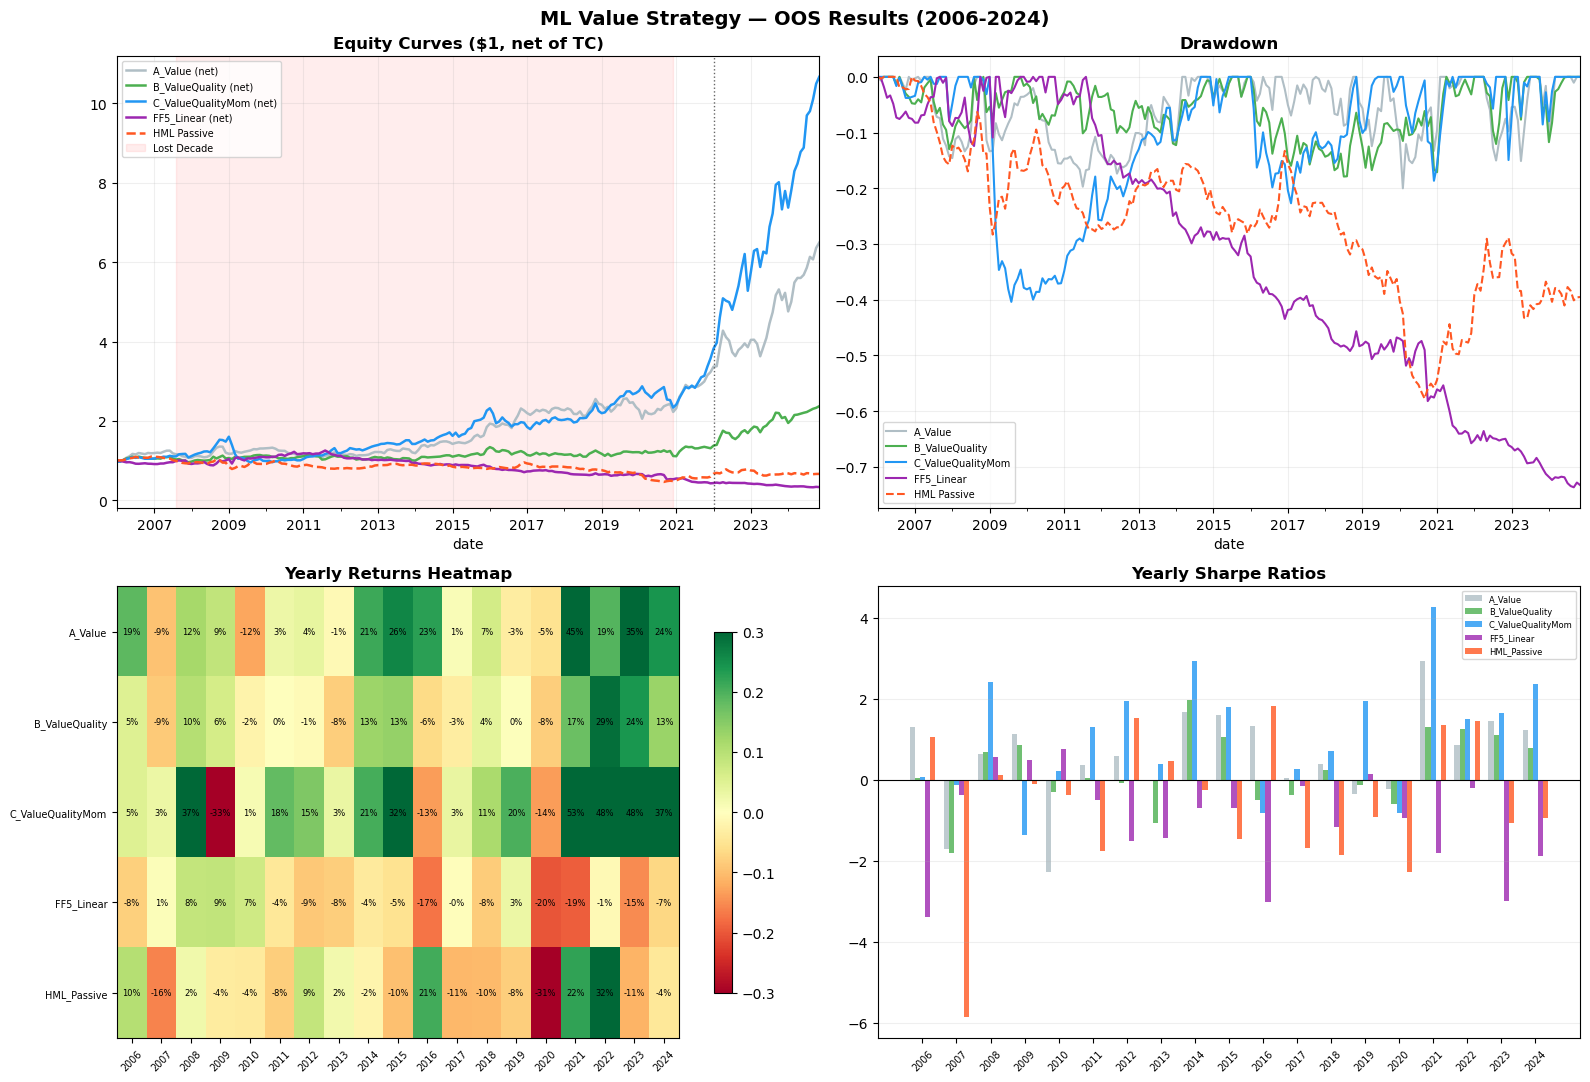

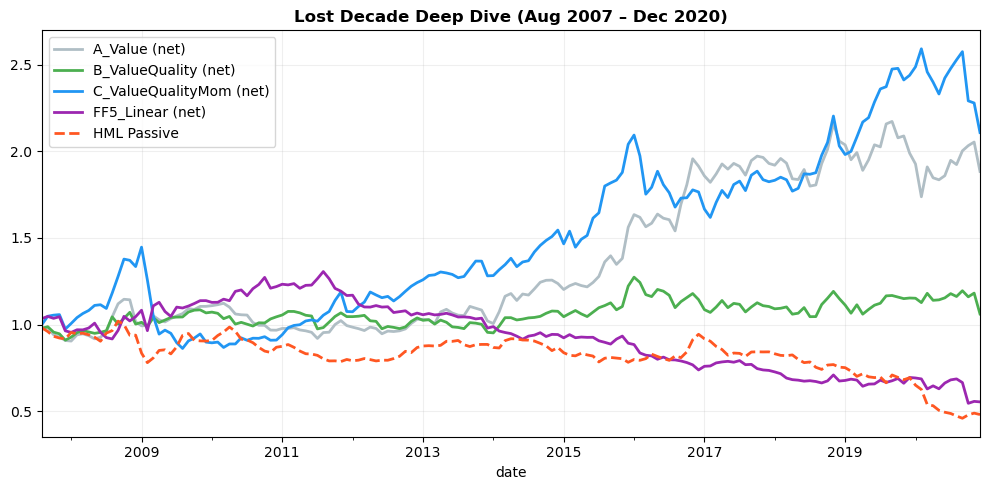

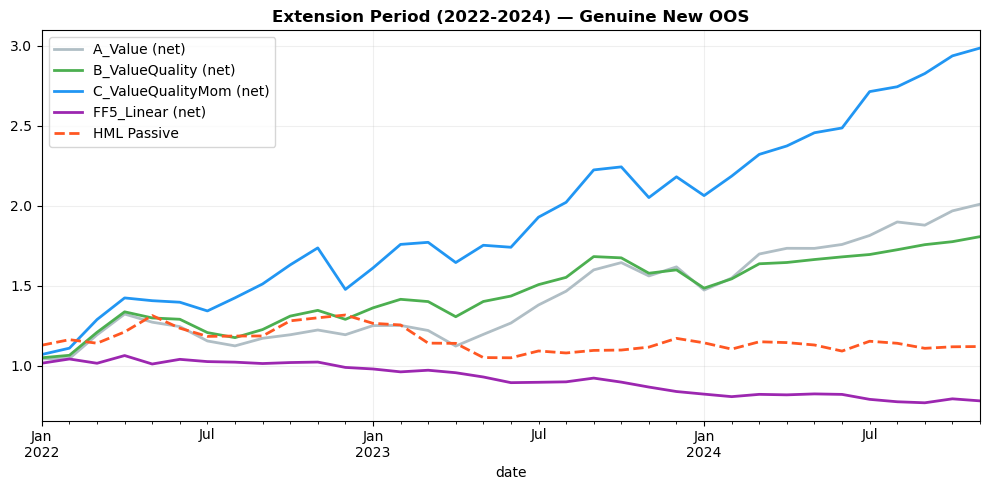


ALL DONE
Output files:
  portfolio_A_Value.csv
  portfolio_B_ValueQuality.csv
  portfolio_C_ValueQualityMom.csv
  portfolio_FF5_benchmark.csv
  yearly_returns.csv
  yearly_sharpe.csv
  ml_value_results.png
  lost_decade.png
  extension_period.png


In [35]:

# ============================================================
# STEP 17: PLOTS
# ============================================================

colors_strat = {
    'A_Value':           '#B0BEC5',
    'B_ValueQuality':    '#4CAF50',
    'C_ValueQualityMom': '#2196F3',
    'FF5_Linear':        '#9C27B0',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('ML Value Strategy — OOS Results (2006-2024)',
             fontsize=14, fontweight='bold')

# --- Plot 1: Equity curves ---
ax = axes[0, 0]
for name, port in portfolios.items():
    (1 + port['ls_ret']).cumprod().plot(
        ax=ax, label=f"{name} (net)",
        color=colors_strat.get(name,'#999'), lw=1.8
    )
(1 + hml.reindex(portfolios['A_Value'].index).dropna()).cumprod().plot(
    ax=ax, label='HML Passive',
    color='#FF5722', lw=1.8, ls='--'
)
ax.axvspan(pd.Timestamp('2007-08-01'),
           pd.Timestamp('2020-12-01'),
           alpha=0.07, color='red', label='Lost Decade')
ax.axvline(pd.Timestamp('2022-01-01'),
           color='black', lw=1, ls=':', alpha=0.6)
ax.set_title('Equity Curves ($1, net of TC)', fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.2)

# --- Plot 2: Drawdown ---
ax = axes[0, 1]
for name, port in portfolios.items():
    cum = (1 + port['ls_ret']).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax()
    dd.plot(ax=ax, label=name,
            color=colors_strat.get(name,'#999'), lw=1.5)
hml_dd_s = hml.reindex(portfolios['A_Value'].index).dropna()
cum_hml  = (1 + hml_dd_s).cumprod()
((cum_hml - cum_hml.cummax()) / cum_hml.cummax()).plot(
    ax=ax, label='HML Passive', color='#FF5722', lw=1.5, ls='--')
ax.set_title('Drawdown', fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.2)

# --- Plot 3: Yearly returns heatmap ---
ax = axes[1, 0]
plot_cols = ['A_Value','B_ValueQuality','C_ValueQualityMom',
             'FF5_Linear','HML_Passive']
plot_cols = [c for c in plot_cols if c in yearly_return.columns]
yr_plot   = yearly_return[plot_cols].dropna(how='all')

im = ax.imshow(yr_plot.T.values, aspect='auto',
               cmap='RdYlGn', vmin=-0.3, vmax=0.3)
ax.set_xticks(range(len(yr_plot.index)))
ax.set_xticklabels(yr_plot.index, rotation=45, fontsize=7)
ax.set_yticks(range(len(plot_cols)))
ax.set_yticklabels(plot_cols, fontsize=7)
for i in range(len(plot_cols)):
    for j in range(len(yr_plot.index)):
        val = yr_plot.iloc[j, i]
        if pd.notna(val):
            ax.text(j, i, f"{val:.0%}",
                    ha='center', va='center', fontsize=6,
                    color='black')
ax.set_title('Yearly Returns Heatmap', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)

# --- Plot 4: Yearly Sharpe bar chart ---
ax = axes[1, 1]
width  = 0.15
x      = np.arange(len(yearly_sharpe.index))
for i, col in enumerate(plot_cols):
    if col in yearly_sharpe.columns:
        vals = yearly_sharpe[col].reindex(yearly_sharpe.index)
        ax.bar(x + i*width,
               vals.fillna(0),
               width,
               label=col,
               color=colors_strat.get(col,'#FF5722'),
               alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x + width*2)
ax.set_xticklabels(yearly_sharpe.index, rotation=45, fontsize=7)
ax.set_title('Yearly Sharpe Ratios', fontweight='bold')
ax.legend(fontsize=6)
ax.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('ml_value_results.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Lost decade zoom ---
fig2, ax2 = plt.subplots(figsize=(10, 5))
for name, port in portfolios.items():
    rets = port['ls_ret']['2007-08-01':'2020-12-01']
    if len(rets) > 0:
        (1 + rets).cumprod().plot(
            ax=ax2, label=f"{name} (net)",
            color=colors_strat.get(name,'#999'), lw=2
        )
hml_ld = hml['2007-08-01':'2020-12-01']
(1 + hml_ld).cumprod().plot(
    ax=ax2, label='HML Passive', color='#FF5722', lw=2, ls='--')
ax2.set_title('Lost Decade Deep Dive (Aug 2007 – Dec 2020)',
              fontweight='bold', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('lost_decade.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Extension zoom ---
fig3, ax3 = plt.subplots(figsize=(10, 5))
for name, port in portfolios.items():
    rets = port['ls_ret']['2022-01-01':]
    if len(rets) > 0:
        (1 + rets).cumprod().plot(
            ax=ax3, label=f"{name} (net)",
            color=colors_strat.get(name,'#999'), lw=2
        )
hml_ext = hml.reindex(
    pd.date_range('2022-01-01','2024-11-01', freq='MS')
).dropna()
(1 + hml_ext).cumprod().plot(
    ax=ax3, label='HML Passive', color='#FF5722', lw=2, ls='--')
ax3.set_title('Extension Period (2022-2024) — Genuine New OOS',
              fontweight='bold', fontsize=12)
ax3.legend()
ax3.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('extension_period.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("ALL DONE")
print("="*70)
print("Output files:")
print("  portfolio_A_Value.csv")
print("  portfolio_B_ValueQuality.csv")
print("  portfolio_C_ValueQualityMom.csv")
print("  portfolio_FF5_benchmark.csv")
print("  yearly_returns.csv")
print("  yearly_sharpe.csv")
print("  ml_value_results.png")
print("  lost_decade.png")
print("  extension_period.png")